In [ ]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE

from collections import Counter

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Indian Population Dataset.xlsx to Indian Population Dataset.xlsx


In [ ]:
df = pd.read_excel("Indian Population Dataset.xlsx")

In [ ]:
df.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density
0,Karnataka,South,67562686,191791,75.86,834
1,Tamil Nadu,South,72147030,130058,24.56,349
2,Kerala,South,35699443,38863,21.66,245
3,Maharashtra,West,124904071,307713,90.97,653
4,Delhi,North,16787941,1484,78.09,765


In [ ]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State          10 non-null     object 
 1   Region         10 non-null     object 
 2   Population     10 non-null     int64  
 3   Area_km2       10 non-null     int64  
 4   Literacy_Rate  10 non-null     float64
 5   Density        10 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 612.0+ bytes


,0
State,0
Region,0
Population,0
Area_km2,0
Literacy_Rate,0
Density,0


In [ ]:
# Create target based on the median
df["Target"] = np.where(df.iloc[:, 1] > df.iloc[:, 1].median(), 1, 0)

print(df["Target"].value_counts())

Target
1    5
0    5
Name: count, dtype: int64


In [ ]:
# Create an imbalanced dataset with enough minority samples

majority = df[df["Target"] == 0]

# Keep 3 minority samples (instead of only 1)
minority = df[df["Target"] == 1].sample(n=3, random_state=42)

imbalanced_df = pd.concat([majority, minority])

# Shuffle the data
imbalanced_df = imbalanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(imbalanced_df["Target"].value_counts())

Target
0    5
1    3
Name: count, dtype: int64


In [ ]:
X = imbalanced_df.drop("Target", axis=1)
y = imbalanced_df["Target"]

In [ ]:
from collections import Counter

print("Before SMOTE")
print(Counter(y))

Before SMOTE
Counter({0: 5, 1: 3})


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("SMOTE applied successfully!")

SMOTE applied successfully!


In [ ]:
print("After SMOTE")
print(Counter(y_resampled))

After SMOTE
Counter({0: 5, 1: 5})


In [ ]:
X_resampled.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density
0,6,1,68548437,342239,63.93,456
1,7,2,72147030,130058,24.56,349
2,1,1,16787941,1484,78.09,765
3,4,2,35699443,38863,21.66,245
4,9,0,91276115,88752,52.72,765


In [ ]:
y_resampled.head()

,Target
0,0
1,1
2,0
3,1
4,0


In [ ]:
print("Original X Shape :", X.shape)
print("Resampled X Shape:", X_resampled.shape)

print("Original y Shape :", y.shape)
print("Resampled y Shape:", y_resampled.shape)

Original X Shape : (8, 6)
Resampled X Shape: (10, 6)
Original y Shape : (8,)
Resampled y Shape: (10,)


In [ ]:
print("Missing values after SMOTE:")
print(X_resampled.isnull().sum())

Missing values after SMOTE:
State            0
Region           0
Population       0
Area_km2         0
Literacy_Rate    0
Density          0
dtype: int64


In [ ]:
print("W2D3 - Handling Imbalanced Data using SMOTE completed successfully!")

W2D3 - Handling Imbalanced Data using SMOTE completed successfully!


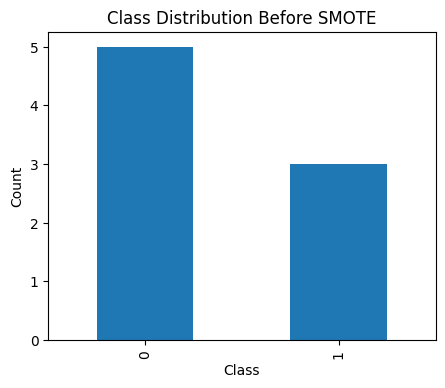

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
y.value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

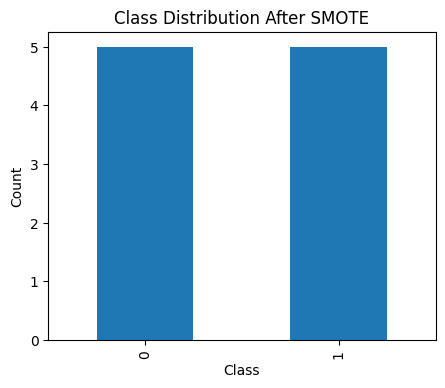

In [ ]:
plt.figure(figsize=(5,4))
y_resampled.value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()